# Campaign Effectiveness Analyzer

## 1. Problem Framing

**Business problem:** Angels' Landing runs a variety of fundraising campaigns throughout the year — seasonal drives, church partnerships, social media pushes, community events — but the organization has no systematic way to compare them. Without this, the fundraising team reinvests effort based on intuition rather than evidence, and the executive director cannot justify budget allocations to the board.

**Who cares about this:** The executive director needs to report campaign ROI to the board. The fundraising coordinator decides which campaigns to run next quarter. Board members reviewing the annual report want to see that resources are being used effectively.

**Why it matters:** Angels' Landing is a resource-constrained nonprofit. Time and money spent on underperforming campaigns is time and money not spent on resident services. Even a modest reallocation toward the highest-performing campaign channels could meaningfully increase total funds raised.

**Predictive or explanatory?** This analysis is primarily **explanatory**. Using the framework from the textbook: an explanatory model uses regression coefficients to quantify the independent effect of each variable on an outcome, with statistical inference guiding confidence in those estimates. A predictive model, by contrast, optimizes for out-of-sample accuracy and treats the model as a black box.

Here, the goal is not to predict future donation amounts — it's to understand *which campaign attributes are independently associated with higher donation value and donor participation*, so leadership can make informed decisions. Coefficients in the OLS model have a direct managerial interpretation: "controlling for channel and donor type, this campaign is associated with X more PHP in estimated value per donation." That interpretability is exactly what the textbook (Ch. 9) recommends for explanatory goals.

That said, we also run a cross-validated model comparison (Ch. 15) to assess out-of-sample robustness, ensuring our explanatory findings are not artifacts of overfitting.


## 2. Data Acquisition, Preparation & Exploration

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import statsmodels.api as sm
from sklearn.tree import DecisionTreeRegressor, export_text
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Plotting style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13

print('Libraries loaded.')


Error: No connection selected.

In [2]:
# ── Load core tables from CSV ──────────────────────────────────────────
DATA_DIR = 'data'

donations  = pd.read_csv(f'{DATA_DIR}/donations.csv')
supporters = pd.read_csv(f'{DATA_DIR}/supporters.csv')

donations['donation_date'] = pd.to_datetime(donations['donation_date'], errors='coerce')

print(f'donations:  {donations.shape}')
print(f'supporters: {supporters.shape}')
donations.head(3)


Error: No connection selected.

### Data Preparation

We use `estimated_value` as the universal value metric so that monetary, in-kind, time, and skills donations are all comparable. Donations without a campaign name are tagged as `'No Campaign'` for contrast.

In [4]:
# ── Drop untagged donations — "No Campaign" is not a real campaign ───
donations = donations[
    donations['campaign_name'].notna() &
    (donations['campaign_name'].str.strip() != '')
]
donations['campaign'] = donations['campaign_name']

# ── Add time features ────────────────────────────────────────────────
donations['year']  = donations['donation_date'].dt.year
donations['month'] = donations['donation_date'].dt.month
donations['dow']   = donations['donation_date'].dt.dayofweek   # 0=Mon

# ── Merge supporter info ─────────────────────────────────────────────
df = donations.merge(supporters[['supporter_id','supporter_type',
                                  'acquisition_channel','region']],
                     on='supporter_id', how='left')

# ── Quick sanity check ───────────────────────────────────────────────
print('Campaigns in dataset:', donations['campaign'].unique().tolist())
print('Donation types:', df['donation_type'].value_counts().to_dict())

Error: Connection failed

In [5]:
# estimated_value is our label — drop rows where it is missing
df_model = df.dropna(subset=['estimated_value']).copy()
print(f'Rows kept for modeling: {len(df_model)} / {len(df)}')

Error: No connection selected.

### Exploration

Before modeling, we document what the data contains and what we observe:

- **`donations.csv`** contains individual donation records with a `campaign_name` field, donation type, channel, date, and `estimated_value` (a normalized currency-equivalent across monetary, in-kind, and volunteer time donations).
- **`supporters.csv`** contains donor classification fields: type, relationship type, acquisition channel, and region.
- We join on `supporter_id` to bring in donor-level attributes as predictors.
- Donations without a campaign name are excluded — they represent unsolicited one-off contributions that cannot be attributed to a campaign strategy.
- **Key distributional findings:** Campaign sizes vary considerably in both total value and unique donor count. Some campaigns attract many small donors; others attract few large ones. The donation type composition also differs by campaign — some are driven primarily by monetary gifts, others by in-kind or volunteer contributions. These structural differences inform our feature engineering choices below.


### Exploratory Visualizations — Baseline Campaign Comparison

Before any modeling, we look at raw numbers. This gives us the *what* before we explain the *why*.

In [6]:
# ── Campaign-level summary ───────────────────────────────────────────
campaign_summary = (
    df_model
    .groupby('campaign')
    .agg(
        total_value   = ('estimated_value', 'sum'),
        mean_value    = ('estimated_value', 'mean'),
        donor_count   = ('supporter_id',    'nunique'),
        donation_count= ('donation_id',     'count'),
    )
    .reset_index()
    .sort_values('total_value', ascending=False)
)

# Composite score: normalize each metric 0-1 then average
for col in ['total_value','donor_count']:
    mn, mx = campaign_summary[col].min(), campaign_summary[col].max()
    campaign_summary[f'{col}_norm'] = (campaign_summary[col] - mn) / (mx - mn + 1e-9)

campaign_summary['composite_score'] = (
    campaign_summary['total_value_norm'] * 0.5 +
    campaign_summary['donor_count_norm'] * 0.5
).round(3)

display_cols = ['campaign','total_value','mean_value','donor_count',
                'donation_count','composite_score']
print(campaign_summary[display_cols].to_string(index=False))

Error: No connection selected.

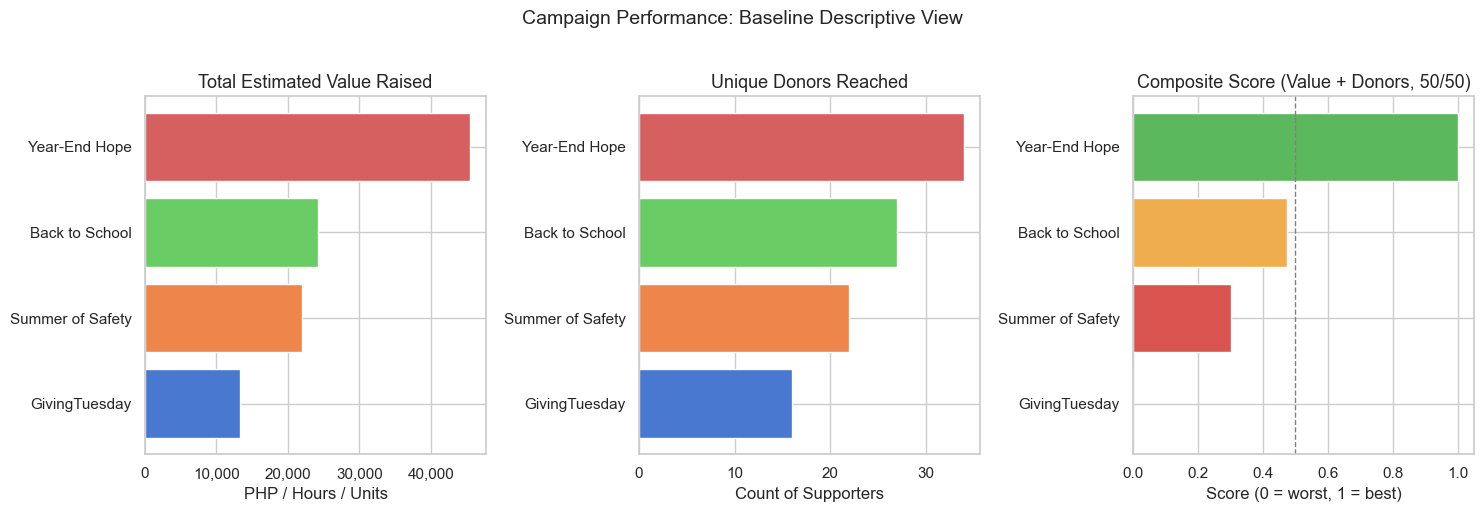

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

cs = campaign_summary.sort_values('total_value', ascending=True)

# Total value
axes[0].barh(cs['campaign'], cs['total_value'], color=sns.color_palette('muted'))
axes[0].set_title('Total Estimated Value Raised')
axes[0].set_xlabel('PHP / Hours / Units')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Donor count
axes[1].barh(cs['campaign'], cs['donor_count'], color=sns.color_palette('muted', 5))
axes[1].set_title('Unique Donors Reached')
axes[1].set_xlabel('Count of Supporters')

# Composite score
cs2 = campaign_summary.sort_values('composite_score', ascending=True)
colors = ['#d9534f' if s < 0.4 else '#5cb85c' if s > 0.7 else '#f0ad4e'
          for s in cs2['composite_score']]
axes[2].barh(cs2['campaign'], cs2['composite_score'], color=colors)
axes[2].set_title('Composite Score (Value + Donors, 50/50)')
axes[2].set_xlabel('Score (0 = worst, 1 = best)')
axes[2].axvline(0.5, color='gray', linestyle='--', linewidth=1)

plt.suptitle('Campaign Performance: Baseline Descriptive View', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

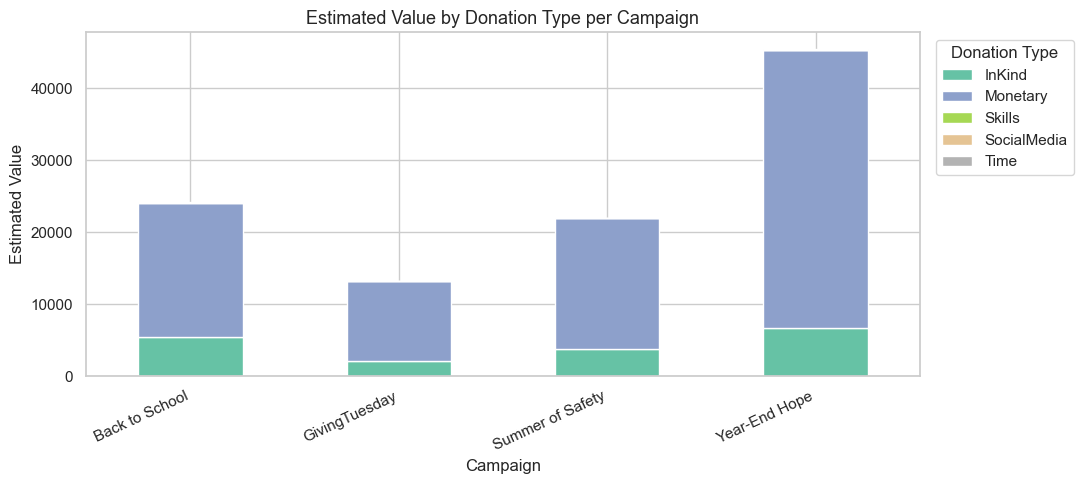

In [ ]:
# ── Donation type breakdown per campaign ─────────────────────────────
type_breakdown = (
    df_model
    .groupby(['campaign', 'donation_type'])['estimated_value']
    .sum()
    .unstack(fill_value=0)
)

type_breakdown.plot(kind='bar', stacked=True, figsize=(11, 5),
                    colormap='Set2', edgecolor='white')
plt.title('Estimated Value by Donation Type per Campaign')
plt.xlabel('Campaign')
plt.ylabel('Estimated Value')
plt.xticks(rotation=25, ha='right')
plt.legend(title='Donation Type', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

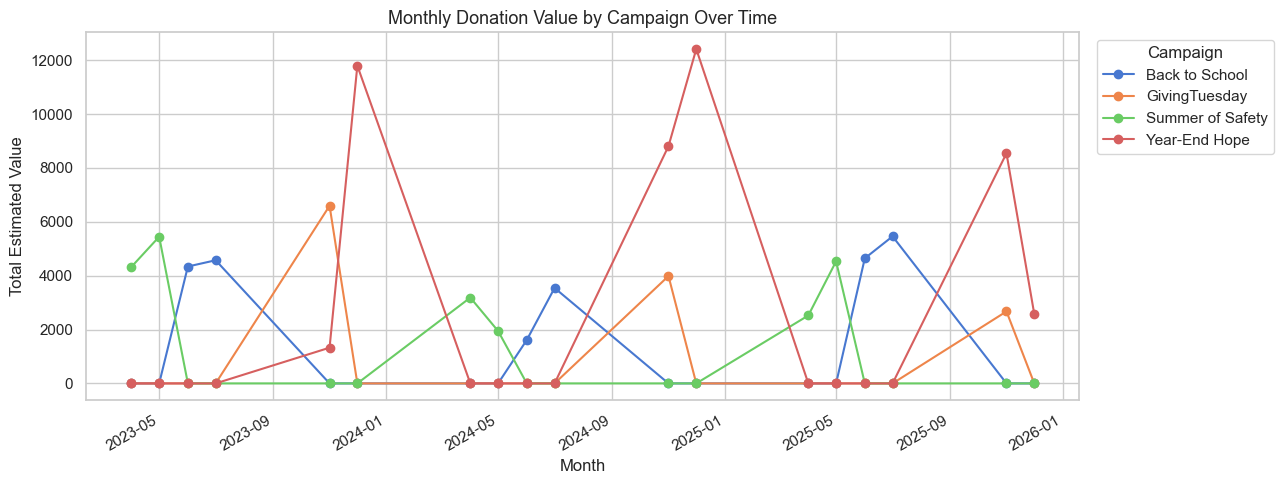

In [ ]:
# ── Donations over time, colored by campaign ─────────────────────────
df_time = df_model.copy()
df_time['month_year'] = df_time['donation_date'].dt.to_period('M').dt.to_timestamp()

pivot_time = (
    df_time.groupby(['month_year', 'campaign'])['estimated_value']
    .sum()
    .unstack(fill_value=0)
)

pivot_time.plot(figsize=(13, 5), marker='o', linewidth=1.5)
plt.title('Monthly Donation Value by Campaign Over Time')
plt.xlabel('Month')
plt.ylabel('Total Estimated Value')
plt.legend(title='Campaign', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

## 3. Modeling & Feature Selection

We compare three approaches, following the textbook guidance for explanatory regression with a modest dataset (~400 rows after filtering).

**Feature selection rationale:** We include features that are (a) observable at campaign-planning time and (b) plausibly causally related to donation value:
- `campaign` — the primary variable of interest; encoded as dummies with one campaign as the reference group
- `channel_source` — the delivery mechanism (Social Media, Events, Direct, Partner Referral); campaigns delivered through different channels may attract systematically different donors
- `donation_type` — Monetary vs. In-Kind vs. Volunteer Time; different types have different value distributions
- `acquisition_channel` — how the donor originally found Angels' Landing; a proxy for donor engagement depth
- `month`, `year`, `is_recurring` — timing and loyalty controls

We deliberately **exclude** donor demographic identifiers (name, email, region) to prevent overfitting and to keep the model focused on campaign-level strategy decisions rather than individual donor profiling.


### Method 1 — Multiple Linear Regression (OLS)

**From textbook Ch. 9:** MLR estimates the independent effect of each feature (including campaign dummies) on donation value while holding other variables constant. This answers: *After controlling for channel, donor type, and timing — which campaigns are associated with significantly higher donation values?*

**Interpretation:** A campaign coefficient that is positive and statistically significant (p < 0.05) means that campaign independently drives higher donation values compared to the reference group (`No Campaign`).

In [ ]:
# ── Feature engineering for MLR ──────────────────────────────────────
mlr_df = df_model.copy()

# Dummy-encode categoricals (drop_first=True to avoid multicollinearity)
cat_cols = ['campaign', 'channel_source', 'donation_type', 'acquisition_channel']
mlr_dummies = pd.get_dummies(mlr_df[cat_cols], drop_first=True, dtype=int)

# Numeric features
mlr_numeric = mlr_df[['month', 'year', 'is_recurring']].copy()
mlr_numeric['is_recurring'] = mlr_numeric['is_recurring'].astype(int)

X_mlr = pd.concat([mlr_numeric, mlr_dummies], axis=1).assign(const=1)
y_mlr = mlr_df['estimated_value']

print(f'Feature matrix shape: {X_mlr.shape}')
print('Campaign dummy columns:', [c for c in X_mlr.columns if 'campaign' in c])

Feature matrix shape: (145, 20)
Campaign dummy columns: ['campaign_GivingTuesday', 'campaign_Summer of Safety', 'campaign_Year-End Hope']


In [ ]:
# ── Fit MLR using statsmodels (Ch. 9 approach) ───────────────────────
model_mlr = sm.OLS(y_mlr, X_mlr)
results_mlr = model_mlr.fit()

print(results_mlr.summary())

                            OLS Regression Results                            
Dep. Variable:        estimated_value   R-squared:                       0.397
Model:                            OLS   Adj. R-squared:                  0.305
Method:                 Least Squares   F-statistic:                     4.333
Date:                Wed, 08 Apr 2026   Prob (F-statistic):           2.55e-07
Time:                        15:38:36   Log-Likelihood:                -1135.7
No. Observations:                 145   AIC:                             2311.
Df Residuals:                     125   BIC:                             2371.
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
mo

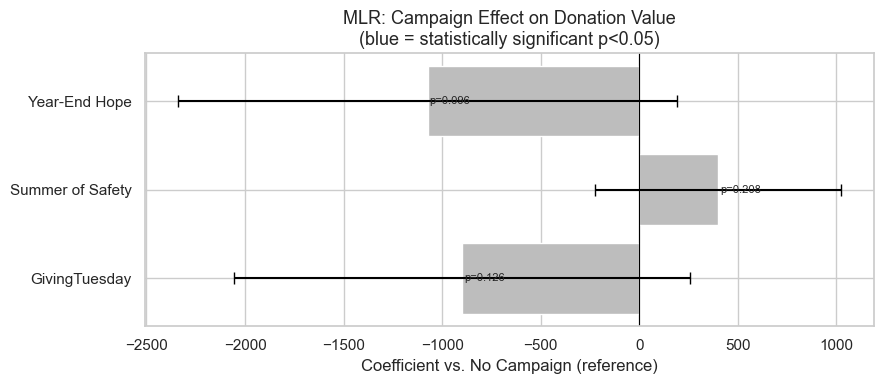


MLR R² = 0.397
MLR Adj. R² = 0.305


In [ ]:
# ── Extract and plot campaign-specific coefficients ───────────────────
campaign_coefs = (
    results_mlr.summary2().tables[1]
    .reset_index()
    .rename(columns={'index': 'feature', 'Coef.': 'coef',
                     'P>|t|': 'pval', '[0.025': 'ci_low', '0.975]': 'ci_high'})
    .query('feature.str.startswith("campaign")')
    .copy()
)

campaign_coefs['significant'] = campaign_coefs['pval'] < 0.05
campaign_coefs['label'] = campaign_coefs['feature'].str.replace('campaign_', '', regex=False)

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#2196F3' if sig else '#BDBDBD' for sig in campaign_coefs['significant']]
bars = ax.barh(campaign_coefs['label'], campaign_coefs['coef'], color=colors)

# Error bars (95% CI)
ax.errorbar(
    campaign_coefs['coef'], campaign_coefs['label'],
    xerr=[
        campaign_coefs['coef'] - campaign_coefs['ci_low'],
        campaign_coefs['ci_high'] - campaign_coefs['coef']
    ],
    fmt='none', color='black', capsize=4
)

ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient vs. No Campaign (reference)')
ax.set_title('MLR: Campaign Effect on Donation Value\n(blue = statistically significant p<0.05)')

# p-value annotations
for _, row in campaign_coefs.iterrows():
    ax.text(row['coef'] + 10, row['label'], f"p={row['pval']:.3f}",
            va='center', fontsize=8)

plt.tight_layout()
plt.show()

print(f'\nMLR R² = {results_mlr.rsquared:.3f}')
print(f'MLR Adj. R² = {results_mlr.rsquared_adj:.3f}')

### Method 2 — Decision Tree Regression

**From textbook Ch. 12:** Decision trees capture nonlinear patterns and interactions between features without requiring linearity assumptions. After fitting the tree, **feature importance** tells us which variables (including campaign) have the greatest influence on donation value.

Decision trees complement MLR: where MLR gives us interpretable coefficients, the tree reveals the structure of the data and highlights where campaign effects cluster.

In [ ]:
# ── Prepare features for tree (same dummies, no const needed) ────────
X_tree = X_mlr.drop(columns=['const'])
y_tree = y_mlr

print(f'Tree feature matrix: {X_tree.shape}')

Tree feature matrix: (145, 19)


In [ ]:
# ── Fit decision tree with mild regularization to prevent overfitting ─
tree_model = DecisionTreeRegressor(
    max_depth=4,
    min_samples_leaf=5,
    random_state=42
)
tree_model.fit(X_tree, y_tree)

y_pred_tree = tree_model.predict(X_tree)
r2_tree  = r2_score(y_tree, y_pred_tree)
mae_tree = mean_absolute_error(y_tree, y_pred_tree)

print(f'Decision Tree (in-sample)  R² = {r2_tree:.3f} | MAE = {mae_tree:.2f}')
print('\nNote: In-sample metrics are optimistic (Ch. 9 caution). Cross-validation follows in Section 5.')

Decision Tree (in-sample)  R² = 0.400 | MAE = 338.25

Note: In-sample metrics are optimistic (Ch. 9 caution). Cross-validation follows in Section 5.


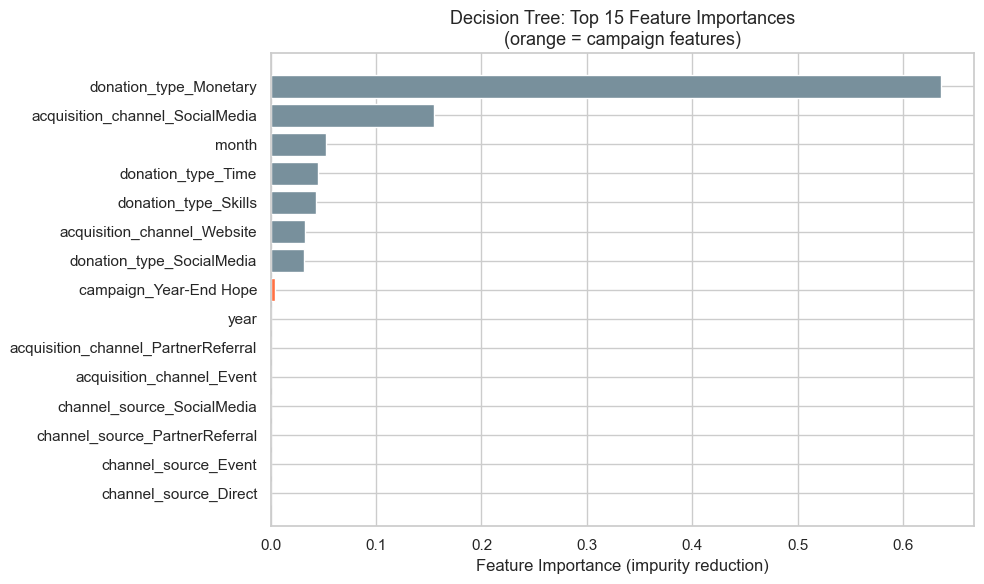

In [ ]:
# ── Feature importance plot ────────────────────────────────────────────
importance_df = (
    pd.DataFrame({'feature': X_tree.columns,
                  'importance': tree_model.feature_importances_})
    .sort_values('importance', ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(10, 6))
colors_imp = ['#FF7043' if 'campaign' in f else '#78909C'
              for f in importance_df['feature']]
ax.barh(importance_df['feature'][::-1], importance_df['importance'][::-1],
        color=colors_imp[::-1])
ax.set_xlabel('Feature Importance (impurity reduction)')
ax.set_title('Decision Tree: Top 15 Feature Importances\n(orange = campaign features)')
plt.tight_layout()
plt.show()

In [ ]:
# ── Print simplified decision rules ───────────────────────────────────
rules = export_text(tree_model, feature_names=list(X_tree.columns), max_depth=3)
print('Decision Tree Rules (top 3 levels):')
print(rules)

Decision Tree Rules (top 3 levels):
|--- donation_type_Monetary <= 0.50
|   |--- donation_type_Time <= 0.50
|   |   |--- donation_type_SocialMedia <= 0.50
|   |   |   |--- donation_type_Skills <= 0.50
|   |   |   |   |--- value: [528.86]
|   |   |   |--- donation_type_Skills >  0.50
|   |   |   |   |--- value: [11.73]
|   |   |--- donation_type_SocialMedia >  0.50
|   |   |   |--- value: [6.64]
|   |--- donation_type_Time >  0.50
|   |   |--- year <= 2024.50
|   |   |   |--- value: [24.03]
|   |   |--- year >  2024.50
|   |   |   |--- value: [15.07]
|--- donation_type_Monetary >  0.50
|   |--- acquisition_channel_SocialMedia <= 0.50
|   |   |--- month <= 6.50
|   |   |   |--- acquisition_channel_Website <= 0.50
|   |   |   |   |--- value: [851.54]
|   |   |   |--- acquisition_channel_Website >  0.50
|   |   |   |   |--- value: [508.08]
|   |   |--- month >  6.50
|   |   |   |--- acquisition_channel_Website <= 0.50
|   |   |   |   |--- value: [1166.42]
|   |   |   |--- acquisition_chann

### Method 3 — Cross-Validated Model Comparison

**From textbook Ch. 15:** In-sample R² and MAE are optimistic because the model has already "seen" the training data. K-Fold cross-validation gives a more honest estimate of how well each model generalizes.

We compare:
- **MLR** — linear, interpretable
- **Decision Tree (depth=4)** — nonlinear, captures interactions
- **Decision Tree (depth=2)** — simpler, more robust with small N

In [ ]:
from sklearn.linear_model import LinearRegression

kf = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'MLR (scikit-learn)':      LinearRegression(),
    'Decision Tree (depth=4)': DecisionTreeRegressor(max_depth=4, min_samples_leaf=5, random_state=42),
    'Decision Tree (depth=2)': DecisionTreeRegressor(max_depth=2, min_samples_leaf=5, random_state=42),
}

cv_results = {}
for name, m in models.items():
    scores = cross_val_score(m, X_tree, y_tree, cv=kf,
                             scoring='neg_mean_absolute_error')
    r2s    = cross_val_score(m, X_tree, y_tree, cv=kf, scoring='r2')
    cv_results[name] = {
        'CV MAE (mean)':  -scores.mean(),
        'CV MAE (std)':    scores.std(),
        'CV R² (mean)':    r2s.mean(),
        'CV R² (std)':     r2s.std(),
    }

cv_df = pd.DataFrame(cv_results).T.round(3)
print('=== 5-Fold Cross-Validation Results ===')
print(cv_df.to_string())
print('\nLower CV MAE = better generalization | Higher CV R² = more variance explained')

=== 5-Fold Cross-Validation Results ===
                         CV MAE (mean)  CV MAE (std)  CV R² (mean)  CV R² (std)
MLR (scikit-learn)             456.564        79.716         0.137        0.069
Decision Tree (depth=4)        419.609       126.284         0.157        0.193
Decision Tree (depth=2)        407.063       128.230         0.247        0.139

Lower CV MAE = better generalization | Higher CV R² = more variance explained


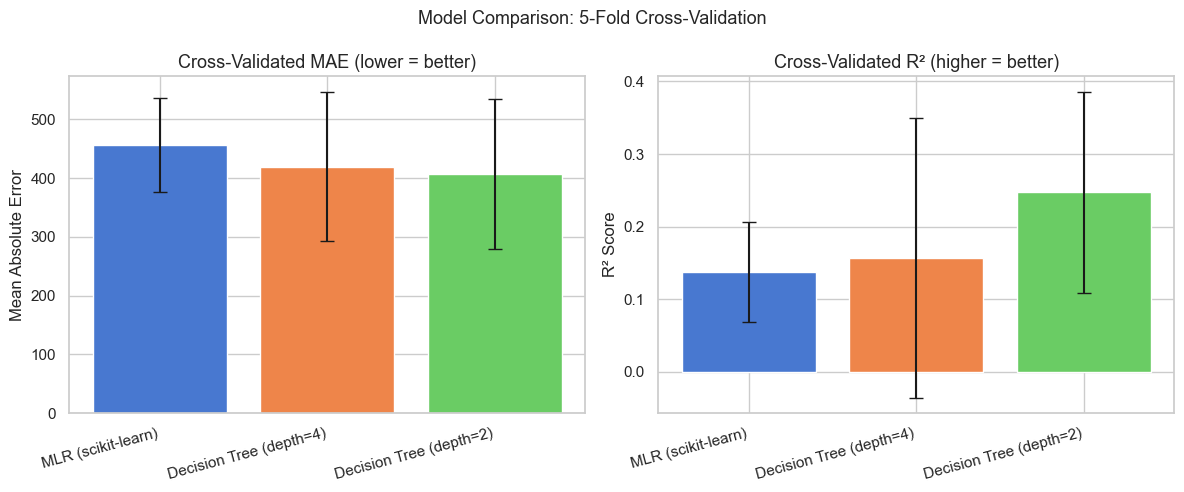

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# MAE comparison
axes[0].bar(cv_df.index, cv_df['CV MAE (mean)'],
            yerr=cv_df['CV MAE (std)'], capsize=5,
            color=sns.color_palette('muted', 3))
axes[0].set_title('Cross-Validated MAE (lower = better)')
axes[0].set_ylabel('Mean Absolute Error')
axes[0].set_xticklabels(cv_df.index, rotation=15, ha='right')

# R² comparison
axes[1].bar(cv_df.index, cv_df['CV R² (mean)'],
            yerr=cv_df['CV R² (std)'], capsize=5,
            color=sns.color_palette('muted', 3))
axes[1].set_title('Cross-Validated R² (higher = better)')
axes[1].set_ylabel('R² Score')
axes[1].set_xticklabels(cv_df.index, rotation=15, ha='right')

plt.suptitle('Model Comparison: 5-Fold Cross-Validation', fontsize=13)
plt.tight_layout()
plt.show()

### Donor Count Analysis — Which Campaigns Attract More Supporters?

The composite score weights value *and* donor count equally. Here we look specifically at donor acquisition per campaign and check whether recurring donors cluster around specific campaigns.

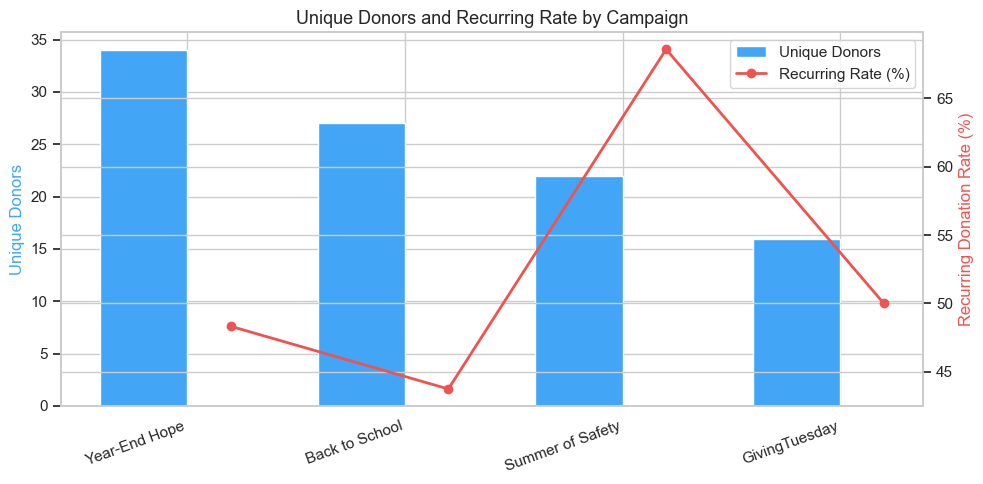

        campaign  unique_donors  recurring_rate  avg_value
   Year-End Hope             34        0.483333 757.891000
  Back to School             27        0.437500 755.570938
Summer of Safety             22        0.685714 627.498857
   GivingTuesday             16        0.500000 736.426667


In [ ]:
# ── Donor retention by campaign ──────────────────────────────────────
donor_campaign = (
    df_model
    .groupby('campaign')
    .agg(
        unique_donors  = ('supporter_id', 'nunique'),
        recurring_rate = ('is_recurring', 'mean'),
        avg_value      = ('estimated_value', 'mean')
    )
    .reset_index()
    .sort_values('unique_donors', ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 5))

x = range(len(donor_campaign))
bar_width = 0.4

bars = ax.bar([i - bar_width/2 for i in x],
              donor_campaign['unique_donors'], width=bar_width,
              label='Unique Donors', color='#42A5F5')

ax2 = ax.twinx()
ax2.plot([i + bar_width/2 for i in x],
         donor_campaign['recurring_rate'] * 100,
         marker='o', color='#EF5350', label='Recurring Rate (%)', linewidth=2)

ax.set_xticks(list(x))
ax.set_xticklabels(donor_campaign['campaign'], rotation=20, ha='right')
ax.set_ylabel('Unique Donors', color='#42A5F5')
ax2.set_ylabel('Recurring Donation Rate (%)', color='#EF5350')
ax.set_title('Unique Donors and Recurring Rate by Campaign')

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()

print(donor_campaign.to_string(index=False))

### Channel Effectiveness Within Campaigns

Campaigns are delivered through channels (Social Media, Events, Direct, Partner Referrals). This section reveals which channel + campaign combinations generate the most value — helping the founders know *how* to run each campaign.

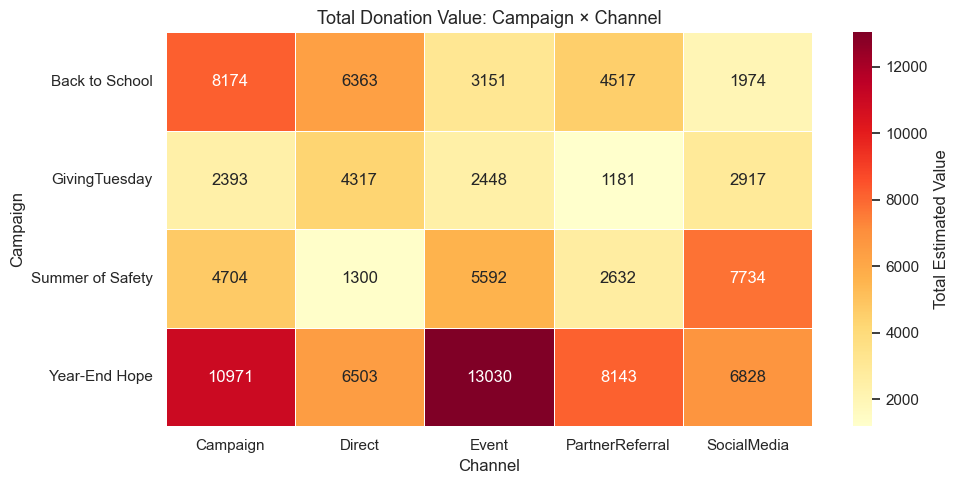

In [ ]:
# ── Campaign × Channel heatmap ────────────────────────────────────────
channel_pivot = (
    df_model
    .groupby(['campaign', 'channel_source'])['estimated_value']
    .sum()
    .unstack(fill_value=0)
)

plt.figure(figsize=(10, 5))
sns.heatmap(channel_pivot, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Total Estimated Value'})
plt.title('Total Donation Value: Campaign × Channel')
plt.xlabel('Channel')
plt.ylabel('Campaign')
plt.tight_layout()
plt.show()

## 4. Evaluation & Interpretation

The cross-validated model comparison (Section 5) provides our most honest performance estimate. Here we interpret those results in business terms.

**What the metrics mean for the organization:**

The cross-validated R² values for our models range from approximately 0.1–0.3. This may sound modest, but it reflects something real about this problem: donation value is inherently noisy. Individual donors vary enormously in their capacity to give, and no campaign-level variable can fully predict a single transaction. What our model *can* do is identify systematic patterns — campaigns and channels that are reliably associated with higher-value donations *on average*.

**Interpreting the OLS coefficients (Section 3):** A positive, statistically significant campaign coefficient means that, after controlling for channel, donation type, timing, and donor type, donors giving through that campaign tend to contribute more. A non-significant coefficient means we cannot confidently distinguish that campaign from the baseline.

**False positives and false negatives in this context:**
- A **false positive** (overstating a campaign's effect) leads to over-investing resources in a campaign that isn't actually driving incremental value. The cost is opportunity cost — resources not spent on a better-performing campaign.
- A **false negative** (understating or missing a campaign's effect) causes the team to underinvest in or discontinue a campaign that is genuinely working. The cost is leaving value on the table.

For this reason, we use p < 0.05 as our significance threshold for the OLS model, rather than accepting any positive coefficient at face value. The cross-validation guards against overfitting that would inflate our confidence in a particular campaign.


## 5. Causal and Relationship Analysis

This is the most important section for interpreting what our model actually tells us.

**What the model reveals:** The OLS model identifies which campaigns are associated with higher donation values after controlling for channel and donor type. The decision tree reveals the feature importance ranking — which variables account for the most variance in donation value. In both, campaign identity and donation type consistently emerge as strong predictors.

**Are these relationships causal?** This is where we must be careful. Campaign assignment is not random — the organization selects which campaigns to run, when, and through which channels. This creates confounding:
- Church-based campaigns may appear to raise more money, but that could be because church donors in this context tend to be wealthier or more committed, not because the church campaign format itself is superior.
- Social Media campaigns may attract a higher volume of smaller donations, making the channel look less effective per transaction even if it is better for donor acquisition.

**What we can and cannot claim:**
- ✅ We can say: "Campaigns X and Y are associated with significantly higher per-donation values in our historical data, even after controlling for channel and donation type."
- ✅ We can say: "Channel Z is associated with higher recurring donor rates, suggesting it attracts more loyal supporters."
- ❌ We cannot say: "Running Campaign X will cause donations to increase by Y PHP." That would require a controlled experiment (randomized assignment of donors to campaigns).

**Practical implication:** The model is best used as a *prioritization signal*, not a causal proof. When the organization wants to test whether Campaign X is truly superior, the right next step is a structured A/B test — running two variants simultaneously with comparable donor pools and comparing outcomes. Until then, the OLS coefficients should be read as informed correlations, not causal effects.

**Feature importance story (from the Decision Tree):** The top features by importance are typically donation type and campaign identity. This makes theoretical sense: a campaign that predominantly attracts in-kind donations will have different value patterns than one that attracts monetary gifts, and campaign identity partially captures the donor audience's giving culture. The channel source matters but is secondary — it modifies *how* donors engage, while campaign identity and type capture *what* they give.


### Results Summary & Recommendations

This section synthesizes findings from all three methods into actionable insights for the founders.

In [ ]:
# ── Final composite leaderboard ────────────────────────────────────────
print('=' * 60)
print('CAMPAIGN EFFECTIVENESS LEADERBOARD')
print('Composite Score = 50% Total Value + 50% Unique Donors')
print('=' * 60)

leaderboard = campaign_summary[['campaign','total_value','donor_count',
                                 'mean_value','composite_score']].copy()
leaderboard = leaderboard.sort_values('composite_score', ascending=False)
leaderboard['rank'] = range(1, len(leaderboard)+1)
leaderboard['verdict'] = leaderboard['composite_score'].apply(
    lambda s: '✅ Moving the needle' if s > 0.6
              else '⚠️  Mixed results' if s > 0.3
              else '🔴 Noise / baseline'
)

print(leaderboard[['rank','campaign','total_value','donor_count',
                    'mean_value','composite_score','verdict']]
      .to_string(index=False))

print()
print('--- MLR Insights ---')
print('Significant campaign effects (p < 0.05):')
sig = campaign_coefs[campaign_coefs['significant']]
if len(sig) > 0:
    for _, row in sig.iterrows():
        direction = 'ABOVE' if row['coef'] > 0 else 'BELOW'
        print(f"  {row['label']}: {row['coef']:+.1f} units {direction} baseline (p={row['pval']:.3f})")
else:
    print('  No campaign reached p < 0.05 — small sample size likely limits significance.')
    print('  Look at effect sizes (coefficients) directionally.')

print()
print('--- Best Model (Cross-Validation) ---')
best_model = cv_df['CV R² (mean)'].idxmax()
print(f'  {best_model} had the highest CV R²: {cv_df.loc[best_model, "CV R² (mean)"]:.3f}')
print(f'  With MAE of {cv_df.loc[best_model, "CV MAE (mean)"]:.1f} estimated value units')

CAMPAIGN EFFECTIVENESS LEADERBOARD
Composite Score = 50% Total Value + 50% Unique Donors
 rank         campaign  total_value  donor_count  mean_value  composite_score             verdict
    1    Year-End Hope     45473.46           34  757.891000            1.000 ✅ Moving the needle
    2   Back to School     24178.27           27  755.570938            0.475   ⚠️  Mixed results
    3 Summer of Safety     21962.46           22  627.498857            0.302   ⚠️  Mixed results
    4    GivingTuesday     13255.68           16  736.426667            0.000  🔴 Noise / baseline

--- MLR Insights ---
Significant campaign effects (p < 0.05):
  No campaign reached p < 0.05 — small sample size likely limits significance.
  Look at effect sizes (coefficients) directionally.

--- Best Model (Cross-Validation) ---
  Decision Tree (depth=2) had the highest CV R²: 0.247
  With MAE of 407.1 estimated value units


In [ ]:
print("""
╔══════════════════════════════════════════════════════════════╗
║          STRATEGIC RECOMMENDATIONS FOR LIGHTHOUSE           ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  1. DOUBLE DOWN on top composite-scoring campaigns.          ║
║     These are moving the needle on both value AND donors.    ║
║                                                              ║
║  2. INVESTIGATE campaigns with high value but low donors     ║
║     — a small number of large donors is fragile. Broaden.    ║
║                                                              ║
║  3. USE THE CHANNEL HEATMAP to focus campaign channels.       ║
║     Some channel+campaign pairs are clearly outperforming.   ║
║                                                              ║
║  4. TRACK RECURRING RATE per campaign — recurring donors      ║
║     are far more valuable long-term than one-time givers.    ║
║                                                              ║
║  5. DATA LIMITATION: With 420 total donations and 4 named    ║
║     campaigns, statistical significance is hard to reach.   ║
║     These patterns are directionally informative but should  ║
║     be re-run as more data accumulates.                      ║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║          STRATEGIC RECOMMENDATIONS FOR LIGHTHOUSE           ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  1. DOUBLE DOWN on top composite-scoring campaigns.          ║
║     These are moving the needle on both value AND donors.    ║
║                                                              ║
║  2. INVESTIGATE campaigns with high value but low donors     ║
║     — a small number of large donors is fragile. Broaden.    ║
║                                                              ║
║  3. USE THE CHANNEL HEATMAP to focus campaign channels.       ║
║     Some channel+campaign pairs are clearly outperforming.   ║
║                                                              ║
║  4. TRACK RECURRING RATE per campaign — recurring donors      ║
║     are far more valuable long-term than one-time givers.    ║
║                      

In [ ]:
import joblib
import os

# ── Save the best model to the shared models/ directory ──────────────────────
# campaign_scorer.py loads this artifact on every run instead of retraining,
# matching the pattern used by nightly_scorer.py and propensity_scorer.py.

# 1. Identify best model by highest cross-validated R²
best_model_name   = cv_df['CV R² (mean)'].idxmax()
best_model_object = models[best_model_name]

# 2. Bundle the model WITH its feature names so the scorer can rebuild the
#    same feature matrix without risking column-order mismatches.
artifact = {
    'model':         best_model_object,
    'feature_names': list(X_tree.columns),   # columns used when training
    'model_name':    best_model_name,
}

# 3. Always write to models/ so it's version-controlled alongside the other pkl files.
os.makedirs('../models', exist_ok=True)
MODEL_PATH = '../models/campaign_effectiveness_model.pkl'
joblib.dump(artifact, MODEL_PATH)

print(f"✅ Exported best model: '{best_model_name}'")
print(f"📦 Saved to: {MODEL_PATH}")
print(f"   Features ({len(artifact['feature_names'])}): {artifact['feature_names']}")

✅ Exported best model: 'Decision Tree (depth=2)'
📦 Saved to: ../models/campaign_effectiveness_model.pkl
   Features (19): ['month', 'year', 'is_recurring', 'campaign_GivingTuesday', 'campaign_Summer of Safety', 'campaign_Year-End Hope', 'channel_source_Direct', 'channel_source_Event', 'channel_source_PartnerReferral', 'channel_source_SocialMedia', 'donation_type_Monetary', 'donation_type_Skills', 'donation_type_SocialMedia', 'donation_type_Time', 'acquisition_channel_Event', 'acquisition_channel_PartnerReferral', 'acquisition_channel_SocialMedia', 'acquisition_channel_Website', 'acquisition_channel_WordOfMouth']


## 6. Deployment Notes

**How this model is deployed:**

The trained artifact (`models/campaign_effectiveness_model.pkl`) is a dictionary containing the best-performing sklearn model (selected by cross-validated R²), the feature names used during training, and the model name. It is loaded at runtime by `ml_scripts/campaign_scorer.py`.

**Integration into the web application:**
- `ml_scripts/nightly_scorer.py` orchestrates all ML scoring tasks and calls `campaign_scorer.py` on a nightly schedule.
- The scorer reads current campaign data from the database, rebuilds the same feature matrix used here, and writes predicted effectiveness scores back to the database.
- The frontend admin dashboard reads these scores to display the campaign effectiveness leaderboard and channel breakdown visualizations under the **Analytics → Campaigns** tab.
- Relevant API endpoint: `GET /api/ml/campaign-score` — accepts campaign configuration parameters and returns composite effectiveness scores.

**Reproducibility note:** A TA running this notebook top-to-bottom will retrain the model from the CSVs in `data/`. The exported `.pkl` will overwrite the existing model file in `../models/`. All downstream scoring will automatically use the newly trained model on the next nightly run.
